<a href="https://colab.research.google.com/github/Xornotor/PPGEEC-CompEvolutiva-Atividades/blob/main/1C_Computa%C3%A7%C3%A3o_Evolutiva_e_Meta_heur%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Avaliação 1C - Computação Evolutiva e Meta-heurísticas**

**Docente:** Prof. Dr. Edmar Egídio Purcino de Souza

**Discentes:** André Paiva, Gabriel Lucas, Márcio Barros e Shaísta Câmara

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numpy import arange
from numpy import exp
from numpy import sqrt
from numpy import cos
from numpy import e
from numpy import pi
from numpy import meshgrid

In [ ]:
# Define the Rastrigin function
def levi(chromosome):
    x1, x2 = chromosome
    term1 = np.sin(3 * np.pi * x1)**2
    term2 = (x1 - 1)**2 * (1 + np.sin(3 * np.pi * x2)**2)
    term3 = (x2 - 1)**2 * (1 + np.sin(2 * np.pi * x2)**2)
    return term1 + term2 + term3

def drop_wave(v):
    x, y = v
    numerator = 1 + np.cos(12 * np.sqrt(x**2 + y**2))
    denominator = 0.5 * (x**2 + y**2) + 2

    # Avoid division by zero
    # Change: Check if any element in the denominator array is zero
    if np.any(denominator == 0):
        # If any element is zero, replace it with a small value to avoid division by zero
        denominator[denominator == 0] = 1e-10 # or any other appropriate value

    return -numerator / denominator

In [ ]:
# Define the PSO algorithm

def pso(cost_func, dim=2, num_particles=30, max_iter=500, w=0.5, c1=1, c2=2,max_patience=50, logprint=False):
    # Initialize particles and velocities
    particles = np.random.uniform(-5.12, 5.12, (num_particles, dim))
    velocities = np.zeros((num_particles, dim))

    # Initialize the best positions and fitness values
    best_positions = np.copy(particles)
    best_fitness = np.array([cost_func(p) for p in particles])
    swarm_best_position = best_positions[np.argmin(best_fitness)]
    swarm_best_fitness = np.min(best_fitness)
    history = []
    patience = 0
    # Iterate through the specified number of iterations, updating the velocity and position of each particle at each iteration
    for i in range(max_iter):
        # Update velocities
        r1 = np.random.uniform(0, 1, (num_particles, dim))
        r2 = np.random.uniform(0, 1, (num_particles, dim))
        velocities = w * velocities + c1 * r1 * (best_positions - particles) + c2 * r2 * (swarm_best_position - particles)

        # Update positions
        particles += velocities

        # Evaluate fitness of each particle
        fitness_values = np.array([cost_func(p) for p in particles])

        # Update best positions and fitness values
        improved_indices = np.where(fitness_values < best_fitness)
        best_positions[improved_indices] = particles[improved_indices]
        best_fitness[improved_indices] = fitness_values[improved_indices]
        if np.min(fitness_values) < swarm_best_fitness:
            swarm_best_position = particles[np.argmin(fitness_values)]
            swarm_best_fitness = np.min(fitness_values)
            patience = 0
        else:
            patience += 1

        if patience == max_patience:
            break

        history.append(swarm_best_fitness)
        if logprint:
            print(f"Iteration {i+1}: Best fitness = {swarm_best_fitness}")

    # Return the best solution found by the PSO algorithm
    return swarm_best_position, swarm_best_fitness, history

In [ ]:
# Define the dimensions of the problem
dim = 2
objective = rastrigin
solution, fitness, history = pso(objective, dim=dim, logprint=True)

# Print the solution and fitness value
print('Solution:', solution)
print('Fitness:', fitness)

Iteration 1: Best fitness = 2.730509486272659
Iteration 2: Best fitness = 2.730509486272659
Iteration 3: Best fitness = 2.7220430414347447
Iteration 4: Best fitness = 2.7220430414347447
Iteration 5: Best fitness = 2.7220430414347447
Iteration 6: Best fitness = 2.7220430414347447
Iteration 7: Best fitness = 1.5226211271091188
Iteration 8: Best fitness = 1.1897630533165113
Iteration 9: Best fitness = 1.0629658383760905
Iteration 10: Best fitness = 1.0629658383760905
Iteration 11: Best fitness = 1.0629658383760905
Iteration 12: Best fitness = 1.0629658383760905
Iteration 13: Best fitness = 1.0028883738468615
Iteration 14: Best fitness = 0.35782957584174113
Iteration 15: Best fitness = 0.35782957584174113
Iteration 16: Best fitness = 0.35782957584174113
Iteration 17: Best fitness = 0.35782957584174113
Iteration 18: Best fitness = 0.35782957584174113
Iteration 19: Best fitness = 0.35782957584174113
Iteration 20: Best fitness = 0.35782957584174113
Iteration 21: Best fitness = 0.0324284540209

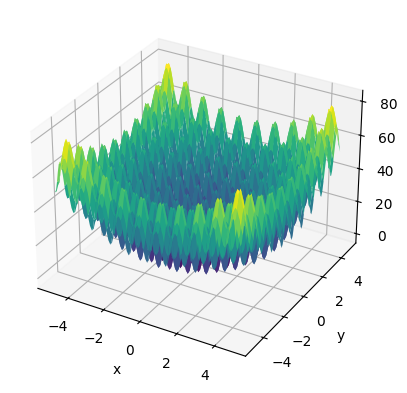

In [ ]:
# Create a meshgrid for visualization
# sample input range uniformly at 0.1 increments
x = arange(-5, 5, 0.1)
y = arange(-5, 5, 0.1)

# x = np.linspace(-5.12, 5.12, 100)
# y = np.linspace(-5.12, 5.12, 100)
X, Y = np.meshgrid(x, y)
Z = objective([X, Y])

# Create a 3D plot of the Rastrigin function
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Plot the solution found by the PSO algorithm
ax.scatter(solution[0], solution[1], fitness, color='red')
plt.show()

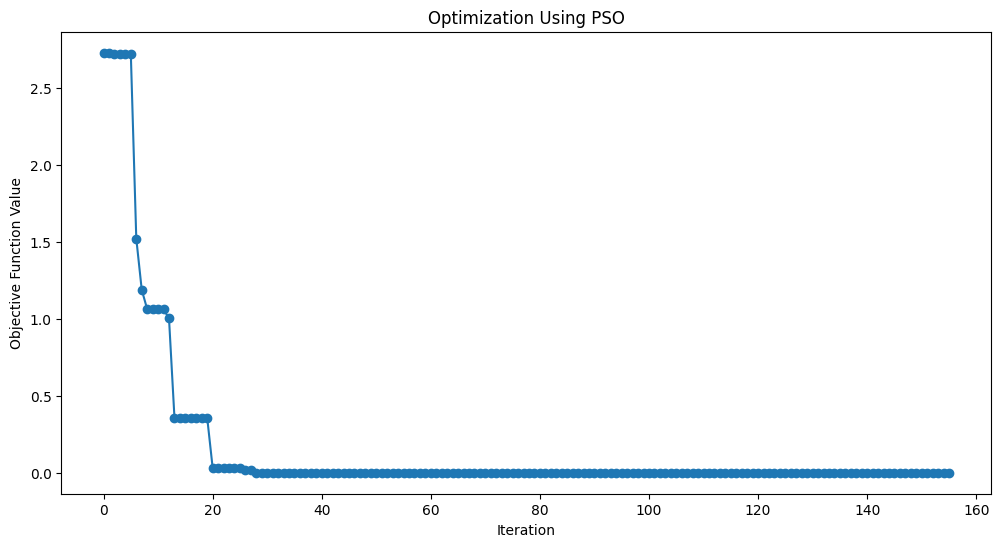

In [ ]:
# Plotting the optimization process
plt.figure(figsize=(12, 6))
plt.plot(history, marker='o')
plt.title('Optimization Using PSO')
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.grid(False)  # Turn off gridlines
plt.show()

## Experimento 1: Número Fixo de Iterações e Inicializações (Drop-Wave).

In [ ]:
# Define the dimensions of the problem
exp1drop_data = []
INIT = 100
dim = 2
objective = drop_wave
for i in range(INIT):
  print(f"\rInicialização {i}...", end='')
  solution, fitness, _ = pso(objective, dim=dim)
  solution = np.append(solution, fitness)
  exp1drop_data.append(solution)
exp1drop_data = np.array(exp1drop_data)
exp1drop_df = pd.DataFrame(exp1drop_data, columns=['X1', 'X2', 'Fitness'])
exp1drop_df

Inicialização 99...

,X1,X2,Fitness
0,-6.072598e-10,-7.900111e-10,-1.0
1,1.363710e-09,-4.846950e-10,-1.0
2,-8.745257e-10,1.145183e-09,-1.0
3,-6.464832e-10,-1.114764e-09,-1.0
4,1.197211e-09,-5.885479e-10,-1.0
...,...,...,...
95,1.065611e-10,-1.028288e-10,-1.0
96,9.719198e-10,-3.118927e-10,-1.0
97,-1.252463e-09,6.941320e-11,-1.0
98,9.360917e-10,-2.011333e-10,-1.0


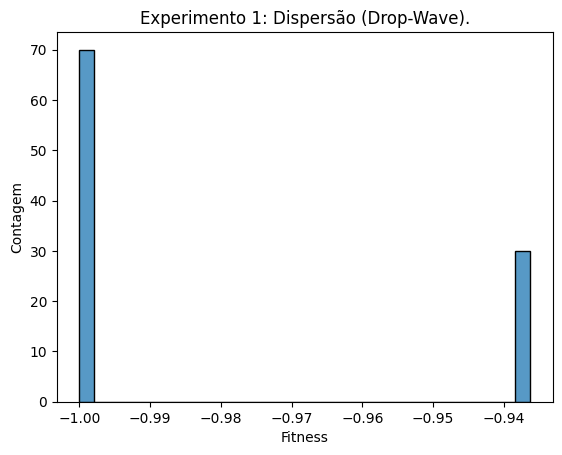

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.histplot(exp1drop_df, x='Fitness', bins=30, ax=ax)
ax.set_title("Experimento 1: Dispersão (Drop-Wave).")
ax.set_ylabel("Contagem")
fig.show()

## Experimento 1: Número Fixo de Iterações e Inicializações (Levi).

In [ ]:
# Define the dimensions of the problem
exp1levi_data = []
INIT = 100
dim = 2
objective = levi
for i in range(INIT):
  print(f"\rInicialização {i}...", end='')
  solution, fitness, _ = pso(objective, dim=dim)
  solution = np.append(solution, fitness)
  exp1levi_data.append(solution)
exp1levi_data = np.array(exp1levi_data)
exp1levi_df = pd.DataFrame(exp1levi_data, columns=['X1', 'X2', 'Fitness'])
exp1levi_df

Inicialização 99...

,X1,X2,Fitness
0,1.0,1.0,1.349784e-31
1,1.0,1.0,1.349784e-31
2,1.0,1.0,1.349784e-31
3,1.0,1.0,1.349784e-31
4,1.0,1.0,1.349784e-31
...,...,...,...
95,1.0,1.0,1.349784e-31
96,1.0,1.0,1.349784e-31
97,1.0,1.0,1.349784e-31
98,1.0,1.0,1.349784e-31


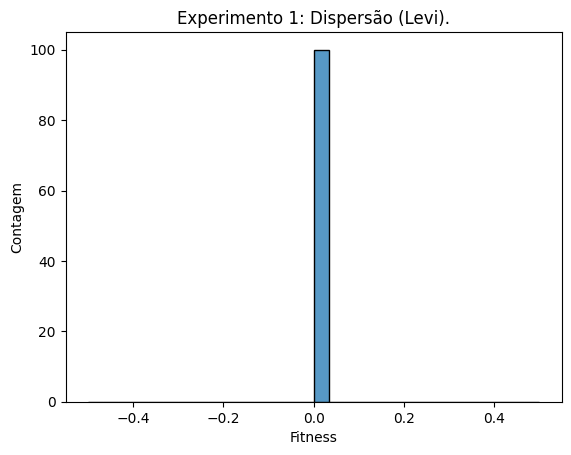

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.histplot(exp1levi_df, x='Fitness', bins=30, ax=ax)
ax.set_title("Experimento 1: Dispersão (Levi).")
ax.set_ylabel("Contagem")
fig.show()

In [ ]:
# Define the dimensions of the problem
exp1_data = []
INIT = 100
dim = 2
objective = drop_wave
for i in range(INIT):
  print(f"\rInicialização {i}...", end='')
  solution, fitness, _ = pso(objective, dim=dim)
  solution = np.append(solution, fitness)
  exp1_data.append(solution)
exp1_data = np.array(exp1_data)
exp1_df = pd.DataFrame(exp1_data, columns=['X1', 'X2', 'Fitness'])
exp1_df

Inicialização 99...

,X1,X2,Fitness
0,-6.072598e-10,-7.900111e-10,-1.0
1,1.363710e-09,-4.846950e-10,-1.0
2,-8.745257e-10,1.145183e-09,-1.0
3,-6.464832e-10,-1.114764e-09,-1.0
4,1.197211e-09,-5.885479e-10,-1.0
...,...,...,...
95,1.065611e-10,-1.028288e-10,-1.0
96,9.719198e-10,-3.118927e-10,-1.0
97,-1.252463e-09,6.941320e-11,-1.0
98,9.360917e-10,-2.011333e-10,-1.0


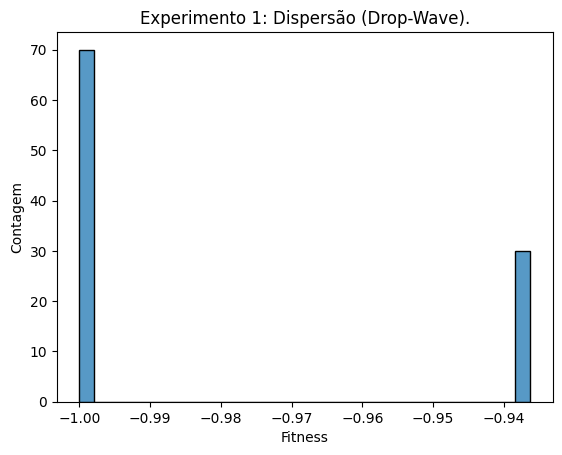

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.histplot(exp1_df, x='Fitness', bins=30, ax=ax)
ax.set_title("Experimento 1: Dispersão (Drop-Wave).")
ax.set_ylabel("Contagem")
fig.show()

## Experimento 2: Excursão do Número de Máximas Iterações (Drop-Wave).

In [ ]:
# Define the dimensions of the problem
exp2drop_data = []
INIT = 100
dim = 2
objective = drop_wave
for max_iter in range(10, 101, 10):
  for i in range(INIT):
    print(f"\rMax.iter. {max_iter}, Inicialização {i}...", end='')
    solution, fitness, _ = pso(objective, dim=dim, max_iter=max_iter, w=0.7) #Mudamos o W
    solution = np.append(solution, fitness)
    solution = np.append(solution, max_iter)
    exp2drop_data.append(solution)
exp2drop_data = np.array(exp2drop_data)
exp2drop_df = pd.DataFrame(exp2drop_data, columns=['X1', 'X2', 'Fitness', 'Máximas Iterações'])
exp2drop_df

Max.iter. 100, Inicialização 99...

,X1,X2,Fitness,Máximas Iterações
0,0.520745,-0.141423,-0.935617,10.0
1,6.048559,-0.548054,-0.935474,10.0
2,1.612844,0.032884,-0.935686,10.0
3,-0.511647,0.088807,-0.936217,10.0
4,0.390923,0.790109,-0.930908,10.0
...,...,...,...,...
995,-0.000005,-0.000989,-0.999965,100.0
996,-0.000020,-0.000009,-1.000000,100.0
997,0.014401,-0.005306,-0.998797,100.0
998,0.000398,-0.000096,-0.999999,100.0


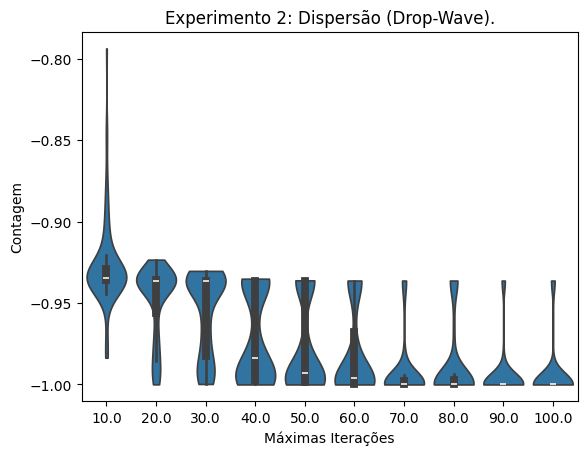

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.violinplot(data=exp2drop_df, x="Máximas Iterações", y="Fitness", ax=ax,
               cut=0, density_norm="width")
ax.set_title("Experimento 2: Dispersão (Drop-Wave).")
ax.set_ylabel("Contagem")
fig.show()

In [ ]:
exp2drop_filt_df = exp2drop_df.groupby(["Máximas Iterações"])[["X1", "X2", "Fitness"]].agg(["mean", "std", "median"])
exp2drop_filt_df

X1                            X2                      \
                       mean       std    median      mean       std    median   
Máximas Iterações                                                               
10.0               0.120992  1.274929 -0.014541 -0.020596  1.183562  0.034616   
20.0               0.108428  1.090616  0.042856 -0.077542  0.803603 -0.010236   
30.0              -0.037424  0.324520 -0.019837 -0.037947  0.404239 -0.000424   
40.0              -0.026421  0.305209 -0.000006 -0.013904  0.308325 -0.001036   
50.0              -0.056842  0.353861 -0.004590  0.020261  0.197202  0.003943   
60.0              -0.009497  0.237397 -0.000161  0.021896  0.211051  0.000270   
70.0              -0.019173  0.161168 -0.000541  0.004330  0.128988  0.000296   
80.0              -0.004619  0.146829 -0.000037 -0.013958  0.172702 -0.000066   
90.0               0.001357  0.098117  0.000024  0.009583  0.146109 -0.000080   
100.0              0.006822  0.107436 -0.000003 -0.000122  0.110119  0.000005   

                    Fitness                      
                       mean       std    median  
Máximas Iterações                                
10.0              -0.927735  0.025744 -0.934853  
20.0              -0.948175  0.022229 -0.936216  
30.0              -0.956149  0.025153 -0.936244  
40.0              -0.971622  0.027398 -0.984085  
50.0              -0.977264  0.027199 -0.992940  
60.0              -0.981353  0.025759 -0.996090  
70.0              -0.992430  0.018288 -0.999730  
80.0              -0.988724  0.022994 -0.999904  
90.0              -0.994689  0.016333 -0.999985  
100.0             -0.994279  0.017661 -0.999999

## Experimento 2: Excursão do Número de Máximas Iterações (Levi).

In [ ]:
# Define the dimensions of the problem
exp2levi_data = []
INIT = 100
dim = 2
objective = levi
for max_iter in range(10, 101, 10):
  for i in range(INIT):
    print(f"\rMax.iter. {max_iter}, Inicialização {i}...", end='')
    solution, fitness, _ = pso(objective, dim=dim, max_iter=max_iter) #Mantivemos o w=0.5
    solution = np.append(solution, fitness)
    solution = np.append(solution, max_iter)
    exp2levi_data.append(solution)
exp2levi_data = np.array(exp2levi_data)
exp2levi_df = pd.DataFrame(exp2levi_data, columns=['X1', 'X2', 'Fitness', 'Máximas Iterações'])
exp2levi_df

Max.iter. 100, Inicialização 99...

,X1,X2,Fitness,Máximas Iterações
0,1.103400,1.141834,2.814194e-02,10.0
1,0.894469,0.833839,1.422487e-02,10.0
2,1.132614,0.082344,1.965535e-01,10.0
3,1.011673,1.148391,4.547104e-02,10.0
4,0.987971,0.939510,1.714703e-02,10.0
...,...,...,...,...
995,1.000000,1.000000,1.777646e-14,100.0
996,1.000000,1.000000,8.697575e-21,100.0
997,1.000000,1.000000,3.033878e-19,100.0
998,1.000000,1.000000,2.074015e-17,100.0


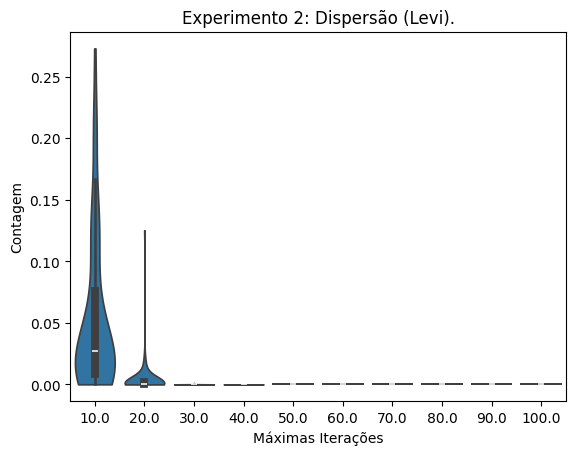

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.violinplot(data=exp2levi_df, x="Máximas Iterações", y="Fitness", ax=ax,
               cut=0, density_norm="width")
ax.set_title("Experimento 2: Dispersão (Levi).")
ax.set_ylabel("Contagem")
fig.show()

In [ ]:
exp2levi_filt_df = exp2levi_df.groupby(["Máximas Iterações"])[["X1", "X2", "Fitness"]].agg(["mean", "std", "median"])
exp2levi_filt_df

X1                                X2            \
                       mean           std    median      mean       std   
Máximas Iterações                                                         
10.0               0.964960  3.811296e-01  0.999190  1.034628  0.344422   
20.0               1.009544  9.457584e-02  0.999849  0.995125  0.078532   
30.0               1.000095  1.155466e-02  1.000028  0.996826  0.015599   
40.0               0.999884  1.254601e-03  0.999996  1.000513  0.003560   
50.0               1.000015  1.288703e-04  0.999999  0.999944  0.001220   
60.0               1.000010  5.097211e-05  1.000000  1.000018  0.000151   
70.0               1.000001  6.760932e-06  1.000000  0.999997  0.000041   
80.0               1.000000  9.471034e-07  1.000000  0.999999  0.000007   
90.0               1.000000  3.557444e-08  1.000000  1.000000  0.000001   
100.0              1.000000  2.824581e-08  1.000000  0.999999  0.000009   

                                  Fitness                              
                     median          mean           std        median  
Máximas Iterações                                                      
10.0               1.004286  5.374493e-02  6.377866e-02  2.698072e-02  
20.0               0.995657  3.597846e-03  1.303222e-02  6.400147e-04  
30.0               0.999628  4.817008e-05  1.374025e-04  5.246315e-06  
40.0               0.999995  2.585908e-06  7.462799e-06  2.287790e-07  
50.0               0.999997  9.258038e-08  3.425443e-07  3.078610e-09  
60.0               1.000002  1.193234e-08  7.370576e-08  1.617110e-10  
70.0               1.000000  7.591340e-11  2.953579e-10  1.433843e-12  
80.0               1.000000  2.080964e-11  1.933567e-10  4.019862e-14  
90.0               1.000000  1.311748e-12  1.135279e-11  1.582330e-15  
100.0              1.000000  9.188669e-15  5.698062e-14  1.083657e-17

## Experimento 3 (Iterações): Excursão do Número de Inicializações (Drop-Wave).

In [ ]:
# Define the dimensions of the problem
exp3drop_data = []
dim = 2
objective = drop_wave
for num_init in range(10, 101, 10):
  for i in range(num_init):
    print(f"\rN de Inicializações. {num_init}, Inicialização {i}...", end='')
    solution, fitness, _ = pso(objective, dim=dim, w=0.7, max_iter=150) #Mudamos o W
    solution = np.append(solution, fitness)
    solution = np.append(solution, num_init)
    exp3drop_data.append(solution)
exp3drop_data = np.array(exp3drop_data)
exp3drop_df = pd.DataFrame(exp3drop_data, columns=['X1', 'X2', 'Fitness', 'Inicializações'])
exp3drop_df

N de Inicializações. 100, Inicialização 99...

,X1,X2,Fitness,Inicializações
0,4.890225e-07,1.334543e-05,-1.000000,10.0
1,4.082937e-05,1.968675e-05,-1.000000,10.0
2,-3.388822e-04,5.493090e-06,-1.000000,10.0
3,1.212983e-05,-1.968982e-06,-1.000000,10.0
4,-4.698506e-01,2.233582e-01,-0.936245,10.0
...,...,...,...,...
545,-1.165730e-04,2.592163e-03,-1.000000,100.0
546,2.491977e-07,-3.438022e-07,-1.000000,100.0
547,-6.405175e-05,1.153331e-05,-1.000000,100.0
548,8.967742e-07,-3.084334e-07,-1.000000,100.0


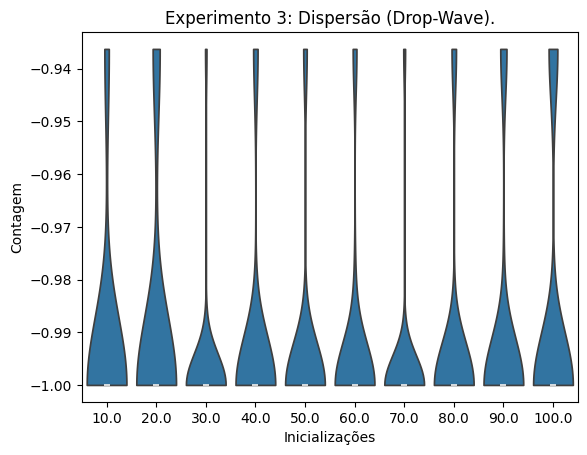

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.violinplot(data=exp3drop_df, x="Inicializações", y="Fitness", ax=ax,
               cut=0, density_norm="width")
ax.set_title("Experimento 3: Dispersão (Drop-Wave).")
ax.set_ylabel("Contagem")
fig.show()

In [ ]:
exp3drop_filt_df = exp3drop_df.groupby(["Inicializações"])[["X1", "X2", "Fitness"]].agg(["mean", "std", "median"])
exp3drop_filt_df

X1                            X2                      \
                    mean       std    median      mean       std    median   
Inicializações                                                               
10.0            0.034978  0.101740  0.000664  0.039058  0.119950  0.000240   
20.0            0.016107  0.125150  0.000010 -0.021559  0.109760  0.000011   
30.0            0.036631  0.111510  0.000037 -0.010466  0.118861 -0.000004   
40.0            0.040267  0.144877  0.000012  0.010437  0.144024  0.000007   
50.0            0.006583  0.126263 -0.000001 -0.017580  0.147177  0.000011   
60.0           -0.009946  0.108925 -0.000013 -0.020816  0.112943 -0.000056   
70.0           -0.002374  0.098573  0.000011  0.000417  0.088288 -0.000040   
80.0            0.015138  0.118130  0.000025 -0.006671  0.099219 -0.000008   
90.0            0.015591  0.110135 -0.000024  0.002478  0.057061 -0.000010   
100.0          -0.000334  0.119723  0.000002  0.009782  0.149323 -0.000002   

                 Fitness                      
                    mean       std    median  
Inicializações                                
10.0           -0.993414  0.020099 -0.999990  
20.0           -0.993617  0.019621 -0.999999  
30.0           -0.993494  0.019414 -0.999997  
40.0           -0.991896  0.021309 -0.999993  
50.0           -0.990958  0.022304 -0.999995  
60.0           -0.993508  0.018135 -0.999995  
70.0           -0.995368  0.015201 -0.999998  
80.0           -0.994299  0.018096 -0.999999  
90.0           -0.996135  0.014720 -0.999999  
100.0          -0.991587  0.021207 -0.999997

## Experimento 3A (Indivíduos): Excursão do Número de Inicializações (Drop-Wave).

In [ ]:
# Define the dimensions of the problem
exp3dropA_data = []
dim = 2
objective = drop_wave
for num_ind in range(10, 100, 10):
  for i in range(INIT):
    print(f"\rN de Indivíduos. {num_ind}, Inicialização {i}...", end='')
    solution, fitness, _ = pso(objective, dim=dim, w=0.7, max_iter=50, num_particles=num_ind) #Mudamos o W
    solution = np.append(solution, fitness)
    solution = np.append(solution, num_ind)
    exp3dropA_data.append(solution)
exp3dropA_data = np.array(exp3dropA_data)
exp3dropA_df = pd.DataFrame(exp3dropA_data, columns=['X1', 'X2', 'Fitness', 'Indivíduos'])
exp3dropA_df

N de Indivíduos. 90, Inicialização 99...

,X1,X2,Fitness,Indivíduos
0,-0.115608,0.485514,-0.936015,10.0
1,-0.216050,0.094797,-0.935117,10.0
2,0.148090,0.319441,-0.935903,10.0
3,0.101168,0.238505,-0.932768,10.0
4,-0.383066,0.388000,-0.936245,10.0
...,...,...,...,...
895,-0.370792,-0.127037,-0.987818,90.0
896,-0.033007,0.061755,-0.997223,90.0
897,0.062565,-0.031398,-0.997215,90.0
898,0.007578,0.070618,-0.978589,90.0


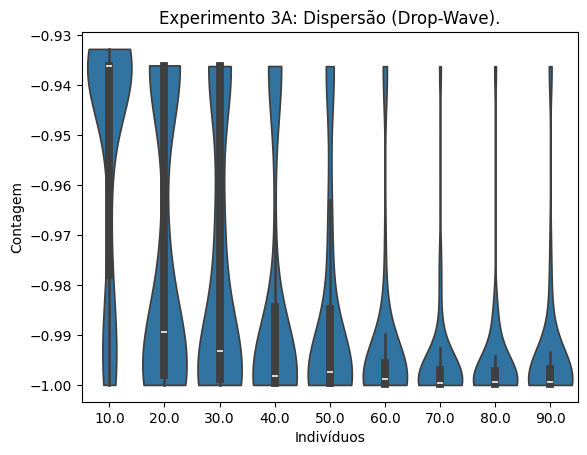

In [ ]:
fig, ax = plt.subplots(1, 1)
sns.violinplot(data=exp3dropA_df, x="Indivíduos", y="Fitness", ax=ax,
               cut=0, density_norm="width")
ax.set_title("Experimento 3A: Dispersão (Drop-Wave).")
ax.set_ylabel("Contagem")
fig.show()

In [ ]:
exp3dropA_filt_df = exp3dropA_df.groupby(["Indivíduos"])[["X1", "X2", "Fitness"]].agg(["mean", "std", "median"])
exp3dropA_filt_df

X1                            X2                      \
                mean       std    median      mean       std    median   
Indivíduos                                                               
10.0       -0.035294  0.311119 -0.017180  0.008972  0.379689 -0.004291   
20.0       -0.031239  0.318313 -0.001523  0.023300  0.211270  0.003508   
30.0        0.027709  0.253181  0.000717  0.034454  0.228791  0.004273   
40.0        0.037762  0.246514  0.001001  0.023789  0.255136  0.001137   
50.0        0.045019  0.233893  0.000969 -0.002234  0.153028 -0.000025   
60.0       -0.046376  0.154441 -0.002483  0.006381  0.145963 -0.001846   
70.0       -0.019621  0.108288 -0.000203  0.002830  0.182525 -0.000041   
80.0       -0.001402  0.140940  0.000264 -0.009957  0.105061 -0.000387   
90.0        0.014991  0.144969  0.000230 -0.001974  0.123788  0.000293   

             Fitness                      
                mean       std    median  
Indivíduos                                
10.0       -0.952343  0.024750 -0.936245  
20.0       -0.972264  0.028475 -0.989383  
30.0       -0.976084  0.026967 -0.993172  
40.0       -0.983761  0.025387 -0.998217  
50.0       -0.986604  0.021465 -0.997390  
60.0       -0.992101  0.017149 -0.998870  
70.0       -0.995129  0.012291 -0.999530  
80.0       -0.995451  0.011689 -0.999389  
90.0       -0.994024  0.014437 -0.999437